In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data")).resolve()

df_per_subject = pd.read_csv(output_dir / "datasets_tidy_per_subject.csv")
df_total = pd.read_csv(output_dir / "datasets_tidy_total.csv")

pivot_per_subject = df_per_subject.pivot_table(index="dataset", columns="dotpath", values="value", aggfunc="first")
pivot_total = df_total.pivot_table(index="dataset", columns="dotpath", values="value", aggfunc="first")
datasets_list = df_per_subject["dataset"].unique().tolist()

print(f"Loaded {len(datasets_list)} dataset(s)")

Loaded 19 dataset(s)


In [2]:
import sys
sys.path.insert(0, str(Path(__file__).resolve().parents[1])) if "__file__" in dir() else sys.path.insert(0, "../")
from analysis.visualisation import make_bubble_chart, make_legend, make_neuroimaging_depthvsbreadth, make_task_composition_radar, DATASET_COLORS
from analysis.tables import COLUMN_GROUPS_PER_SUBJECT, COLUMN_GROUPS_TOTAL

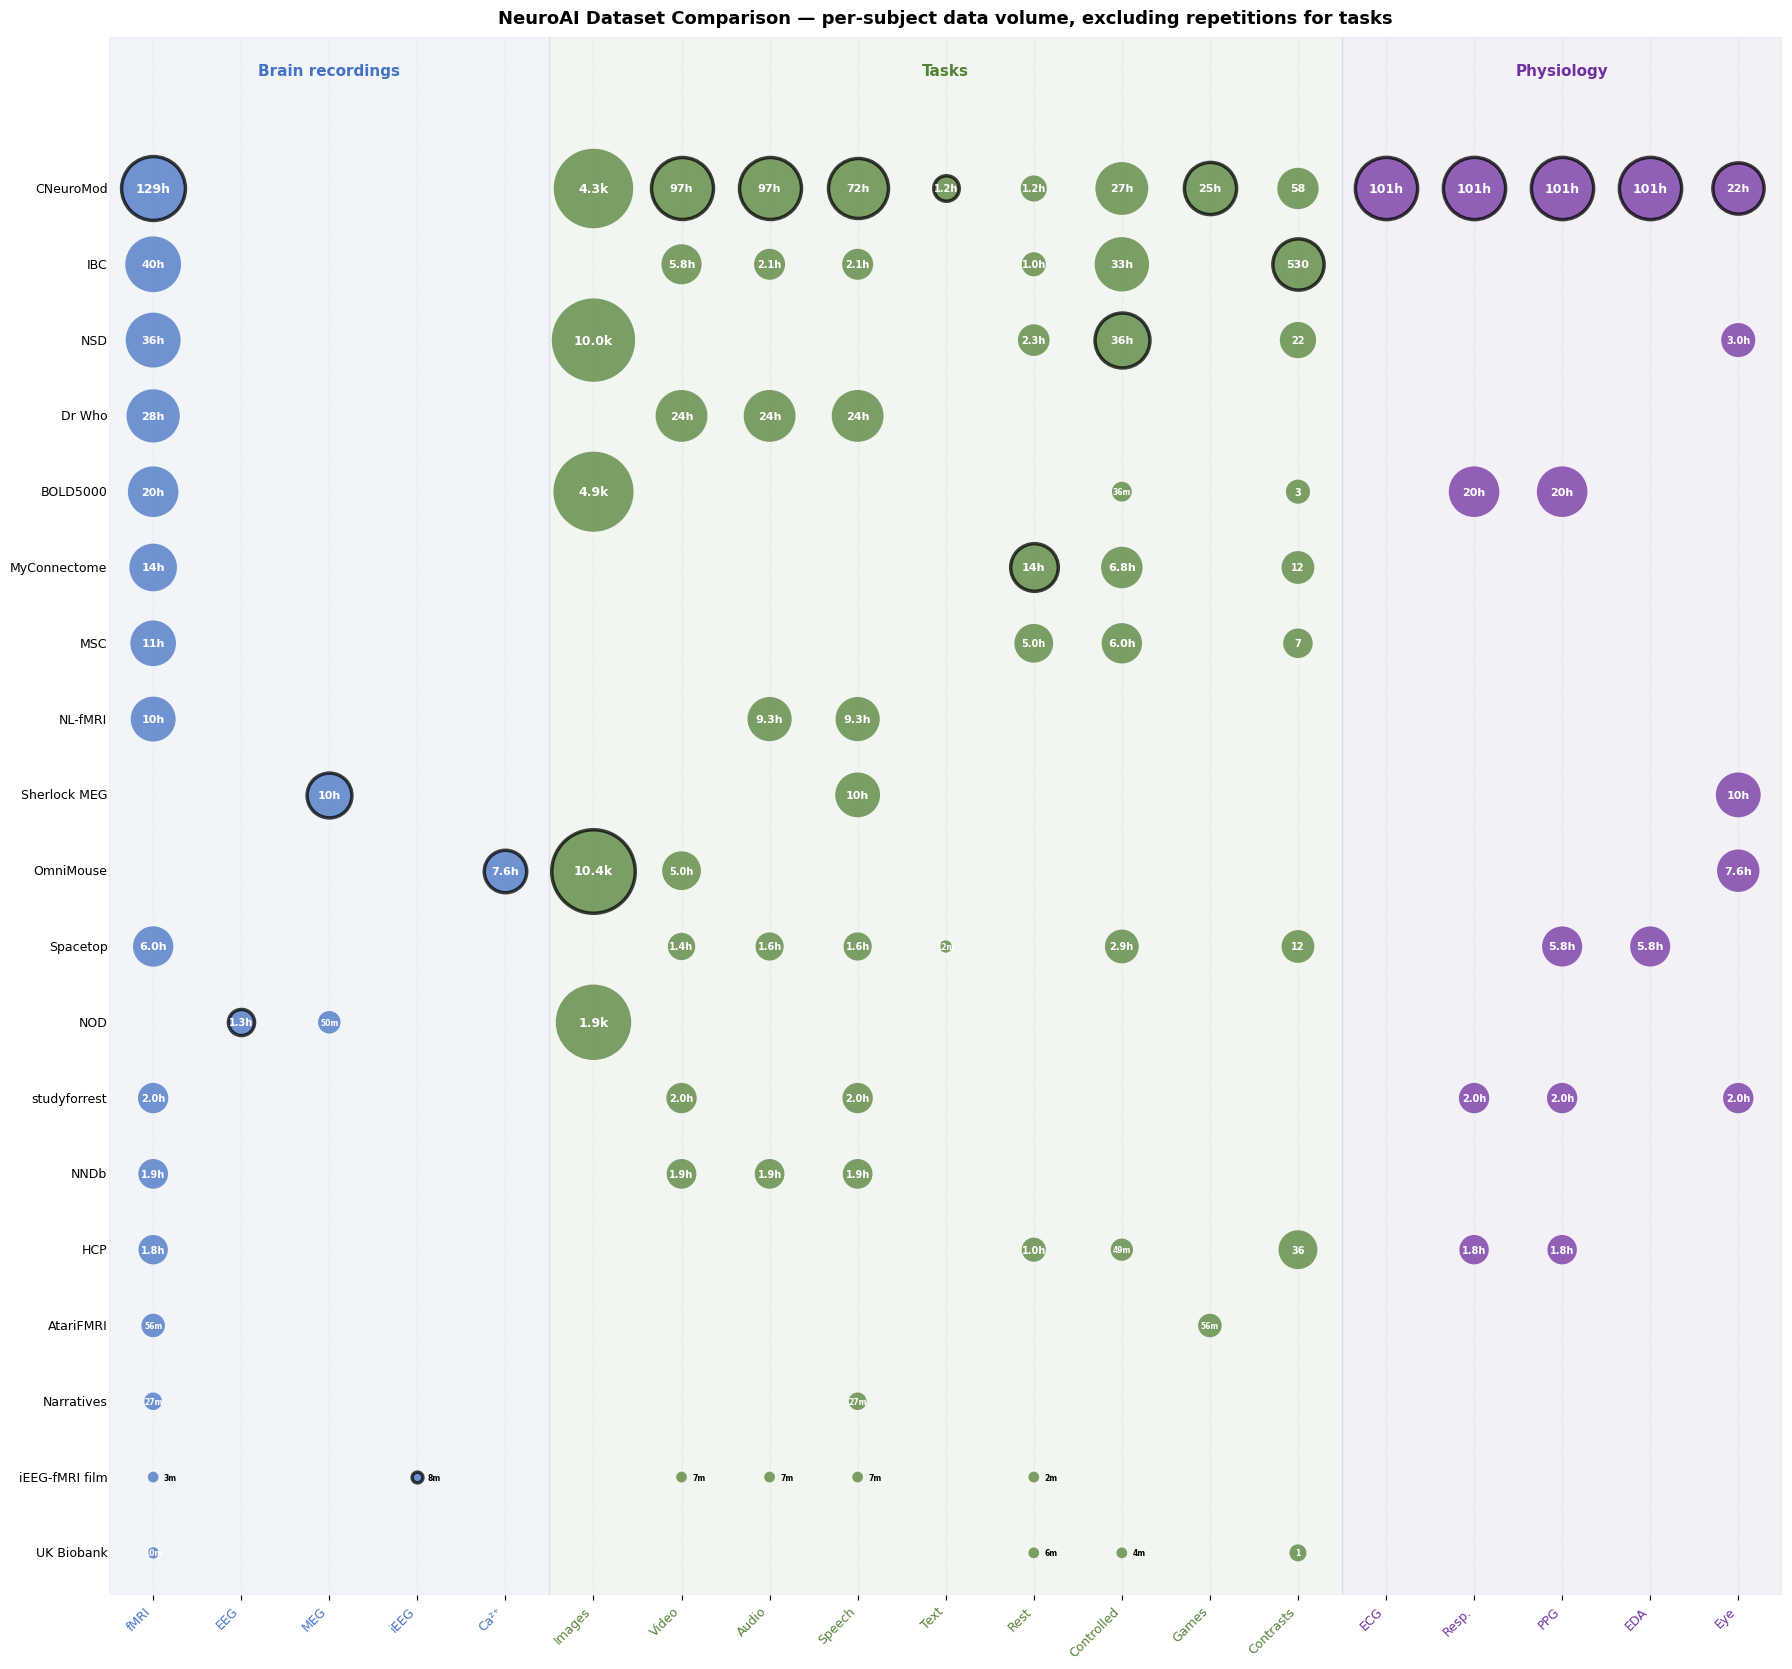

Saved dataset_comparison_per_subject.png


In [3]:
make_bubble_chart(
    COLUMN_GROUPS_PER_SUBJECT,
    pivot_per_subject,
    datasets_list,
    "NeuroAI Dataset Comparison — per-subject data volume, excluding repetitions for tasks",
    output_dir / "dataset_comparison_per_subject.png",
)

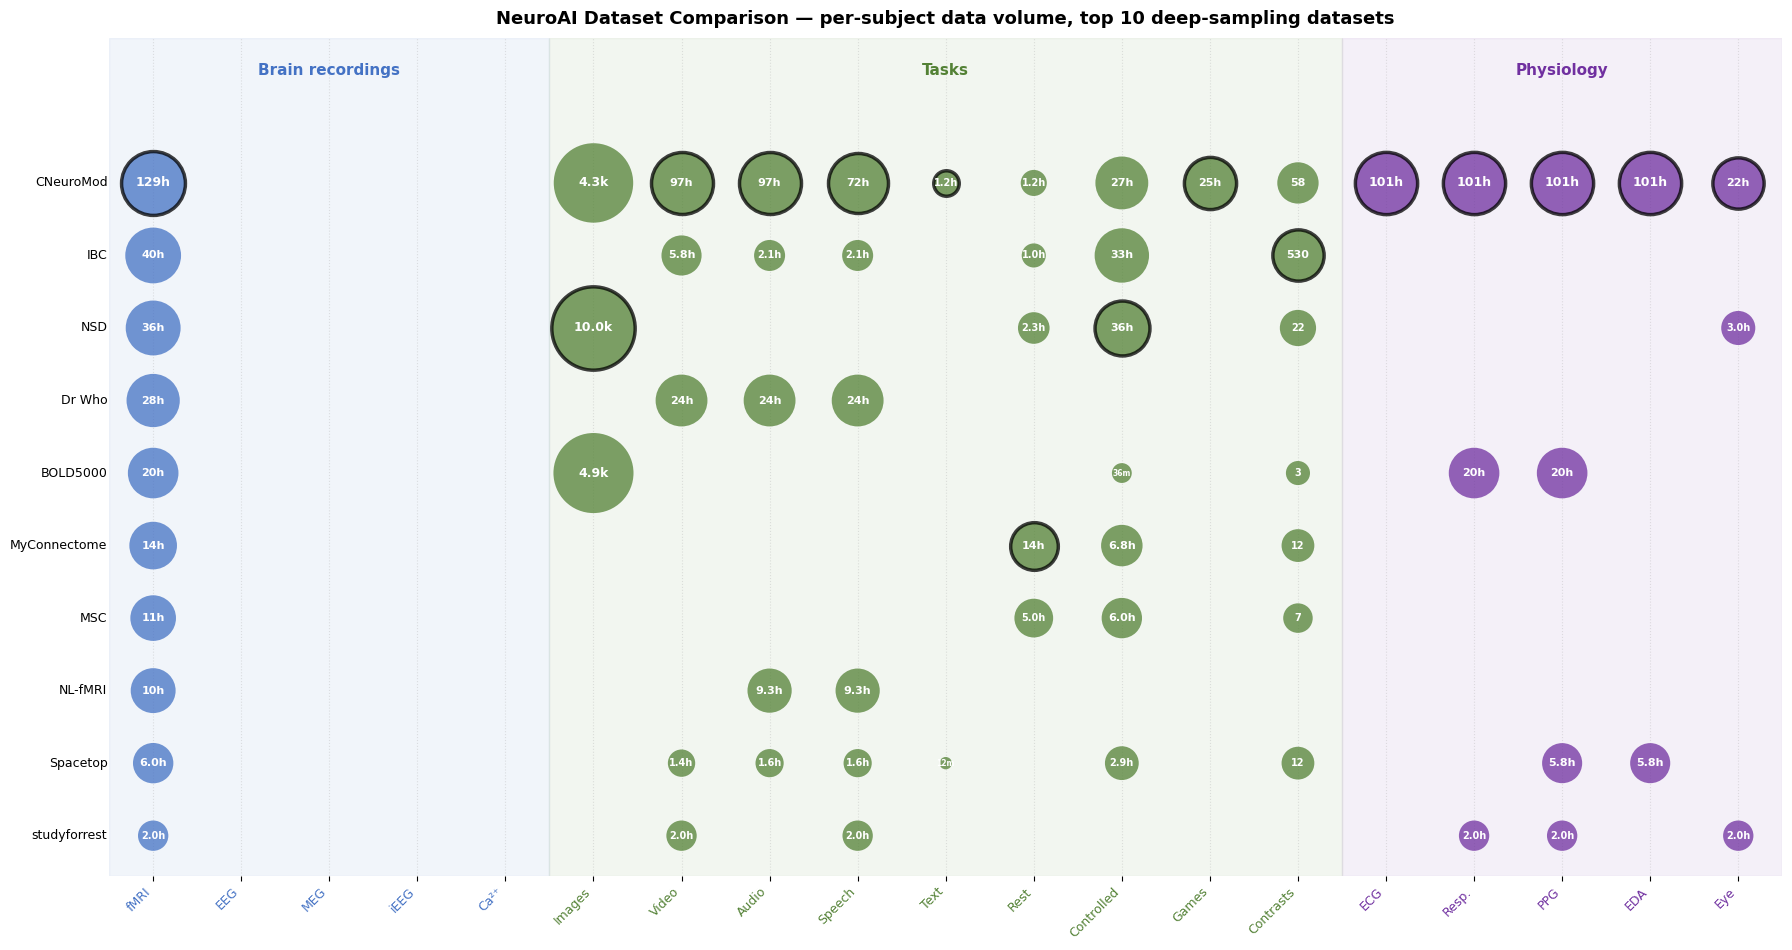

Saved dataset_comparison_per_subject_short.png


In [4]:
EXCLUDE = {"OmniMouse", "UK Biobank", "HCP"}
fmri_col = "neuroimaging.fmri.per_subject_h"
datasets_filtered = [
    ds for ds in datasets_list if ds not in EXCLUDE
]
datasets_top10 = sorted(
    datasets_filtered,
    key=lambda ds: float(pivot_per_subject.loc[ds, fmri_col]) if ds in pivot_per_subject.index and fmri_col in pivot_per_subject.columns and pd.notna(pivot_per_subject.loc[ds, fmri_col]) else 0.0,
    reverse=True,
)[:10]

make_bubble_chart(
    COLUMN_GROUPS_PER_SUBJECT,
    pivot_per_subject,
    datasets_top10,
    "NeuroAI Dataset Comparison — per-subject data volume, top 10 deep-sampling datasets",
    output_dir / "dataset_comparison_per_subject_short.png",
)

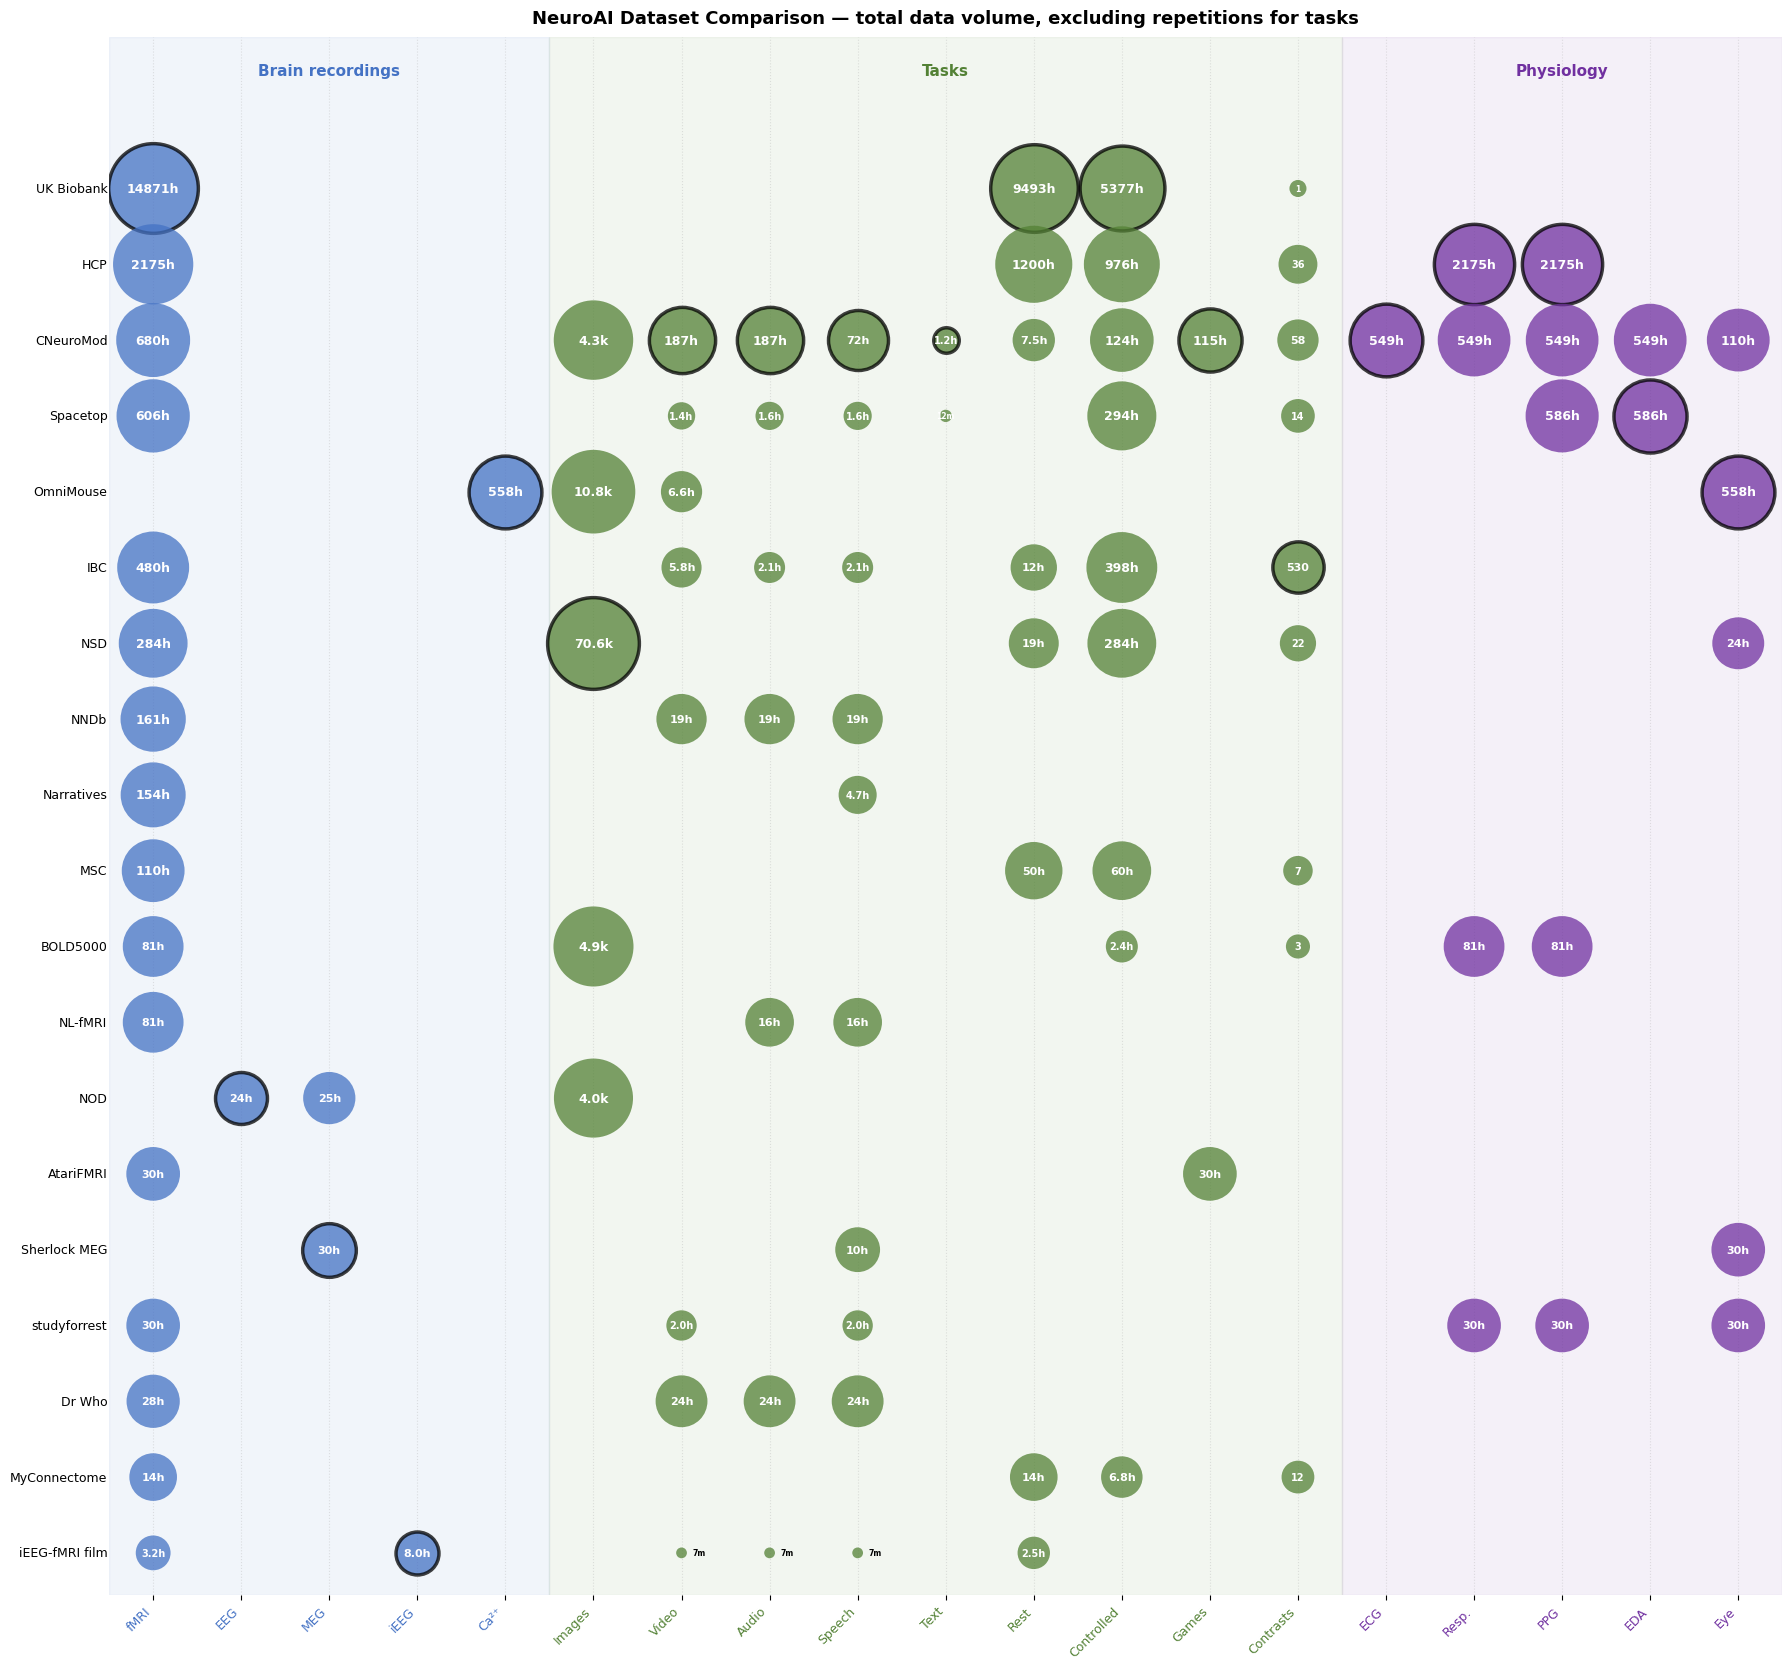

Saved dataset_comparison_total.png


In [5]:
make_bubble_chart(
    COLUMN_GROUPS_TOTAL,
    pivot_total,
    datasets_list,
    "NeuroAI Dataset Comparison — total data volume, excluding repetitions for tasks",
    output_dir / "dataset_comparison_total.png",
)

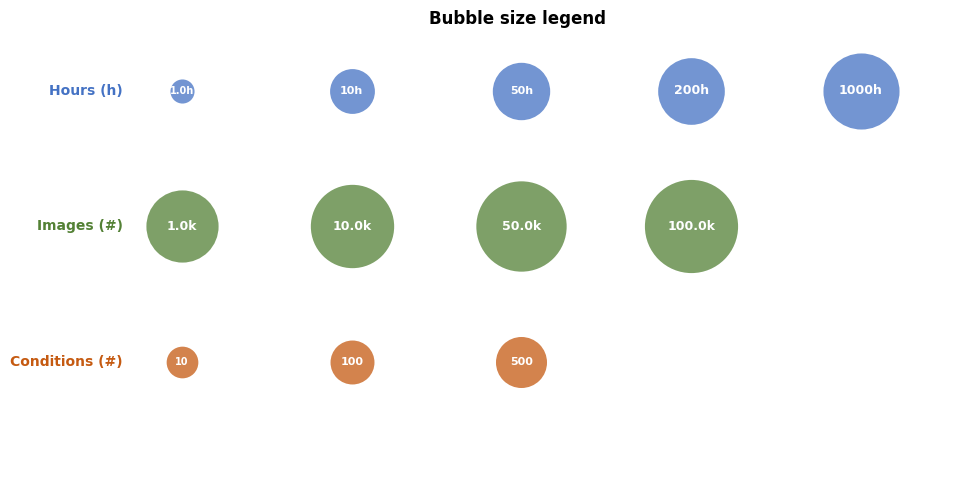

Saved dataset_comparison_legend.png


In [6]:
make_legend(output_dir / "dataset_comparison_legend.png")

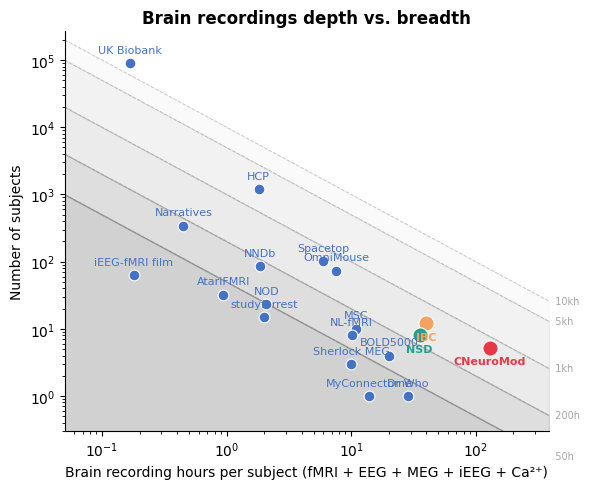

Saved dataset_neuroimaging_depthvsbreadth.png


In [7]:
make_neuroimaging_depthvsbreadth(
    pivot_per_subject,
    pivot_total,
    datasets_list,
    output_dir / "dataset_neuroimaging_depthvsbreadth.png",
    highlights={ds: DATASET_COLORS[ds] for ds in DATASET_COLORS if ds in datasets_list},
    column_groups_per_subject=COLUMN_GROUPS_PER_SUBJECT,
    column_groups_total=COLUMN_GROUPS_TOTAL,
)

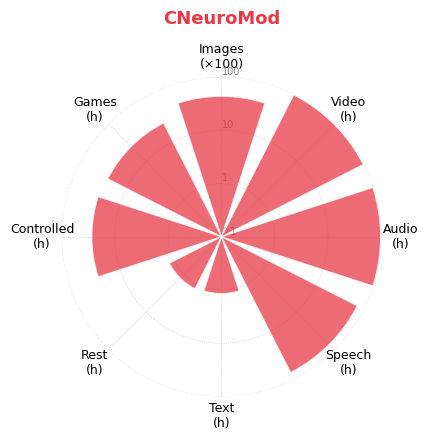

Saved dataset_task_composition_radar_cneuromod.png


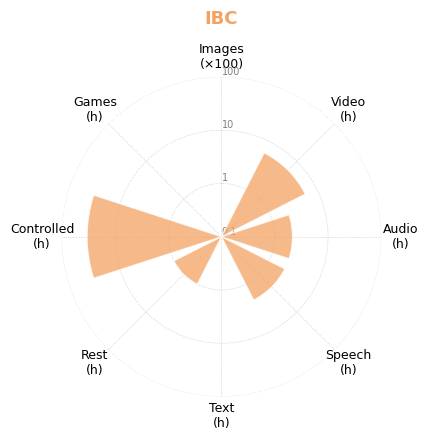

Saved dataset_task_composition_radar_ibc.png


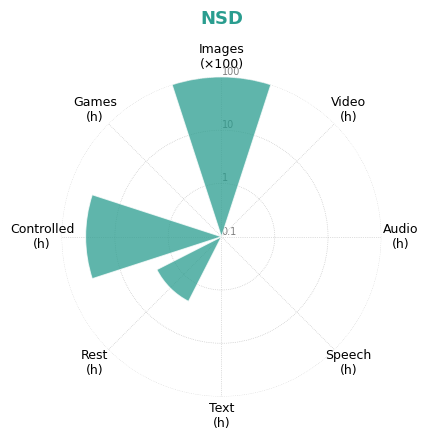

Saved dataset_task_composition_radar_nsd.png


In [8]:
from analysis.visualisation import make_task_composition_radar, RADAR_TASK_FIELDS, DATASET_COLORS

RADAR_DATASETS = ["CNeuroMod", "IBC", "NSD"]

# Compute shared radial max across all three datasets so figures are panel-comparable
import numpy as np
all_vals = []
for ds in RADAR_DATASETS:
    for _, path, div in RADAR_TASK_FIELDS:
        if ds in pivot_per_subject.index and path in pivot_per_subject.columns:
            v = pivot_per_subject.loc[ds, path]
            if pd.notna(v) and v > 0:
                all_vals.append(float(v) / div)
r_max = max(all_vals) if all_vals else 100.0

for dataset in RADAR_DATASETS:
    make_task_composition_radar(
        pivot_per_subject,
        dataset,
        output_dir / f"dataset_task_composition_radar_{dataset.lower()}.png",
        r_max=r_max,
    )